In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [261]:
df = pd.read_csv("C:\\Users\\Tushar\\Documents\\Car Prediction\\cars_dataset.csv")
df.head()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Year               6019 non-null   int64  
 2   Kilometers_Driven  6019 non-null   int64  
 3   Fuel_Type          6019 non-null   object 
 4   Transmission       6019 non-null   object 
 5   Owner_Type         6019 non-null   object 
 6   Mileage            6017 non-null   object 
 7   Engine             5983 non-null   object 
 8   Power              5983 non-null   object 
 9   Seats              5977 non-null   float64
 10  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 517.4+ KB


In [263]:
df.isnull().sum()

Name                  0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64

In [264]:
df = df.dropna(subset=['Engine','Seats','Mileage',"Power"])

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5975 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Year               5975 non-null   int64  
 2   Kilometers_Driven  5975 non-null   int64  
 3   Fuel_Type          5975 non-null   object 
 4   Transmission       5975 non-null   object 
 5   Owner_Type         5975 non-null   object 
 6   Mileage            5975 non-null   object 
 7   Engine             5975 non-null   object 
 8   Power              5975 non-null   object 
 9   Seats              5975 non-null   float64
 10  Price              5975 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 560.2+ KB


In [266]:
df.isnull().sum()

Name                 0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [267]:
df.nunique()

Name                 1855
Year                   22
Kilometers_Driven    3080
Fuel_Type               4
Transmission            2
Owner_Type              4
Mileage               442
Engine                145
Power                 371
Seats                   9
Price                1369
dtype: int64

In [268]:
df["Name"] = df["Name"].str.replace(" ", "")
df["Mileage"] = df["Mileage"].str.extract(r'(\d+\.?\d*)')
df["Engine"] = df["Engine"].str.extract(r'(\d+\.?\d*)')
df["Power"] = df["Power"].str.extract(r'(\d+\.?\d*)')

In [269]:
df.tail()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
6014,MarutiSwiftVDI,2014,27365,Diesel,Manual,First,28.4,1248,74,5.0,4.75
6015,HyundaiXcent1.1CRDiS,2015,100000,Diesel,Manual,First,24.4,1120,71,5.0,4.00
6016,MahindraXyloD4BSIV,2012,55000,Diesel,Manual,Second,14.0,2498,112,8.0,2.90
6017,MarutiWagonRVXI,2013,46000,Petrol,Manual,First,18.9,998,67.1,5.0,2.65
6018,ChevroletBeatDiesel,2011,47000,Diesel,Manual,First,25.44,936,57.6,5.0,2.50


In [270]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Name"] = le.fit_transform(df["Name"])
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Transmission"] = le.fit_transform(df["Transmission"])
df["Owner_Type"] = le.fit_transform(df["Owner_Type"])
df.head()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1179,2010,72000,0,1,0,26.6,998,58.16,5.0,1.75
1,502,2015,41000,1,1,0,19.67,1582,126.2,5.0,12.50
2,476,2011,46000,3,1,0,18.2,1199,88.7,5.0,4.50
3,1043,2012,87000,1,1,0,20.77,1248,88.76,7.0,6.00
4,23,2013,40670,1,0,2,15.2,1968,140.8,5.0,17.74


In [271]:
df["Mileage"].value_counts()

Mileage
18.9     172
17.0     171
18.6     119
20.36     88
21.1      87
        ... 
9.7        1
27.28      1
14.57      1
14.33      1
17.24      1
Name: count, Length: 430, dtype: int64

In [272]:
df = df[df["Name"].map(df["Name"].value_counts()) > 5]

In [273]:
df["Name"].value_counts()

Name
908     49
1138    45
1114    34
409     34
1139    31
        ..
1710     6
1149     6
1041     6
666      6
749      6
Name: count, Length: 263, dtype: int64

In [274]:
X = df.drop(['Price'], axis=1)
X.dropna()
X = X.dropna()
X.isnull().sum()

Name                 0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

In [275]:
Y = df["Price"]
Y = Y.loc[X.index]

In [276]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.25, random_state=42)

In [277]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[ 1.75633029,  1.65266982, -0.65156116, ..., -0.07287796,
        -0.38547892, -0.38699743],
       [-0.39414071,  0.14009776,  0.06275965, ..., -0.6154168 ,
        -0.59502422, -0.38699743],
       [-0.86619532,  0.51824077, -0.53156218, ..., -0.07468041,
         0.28921089, -0.38699743],
       ...,
       [ 0.027406  ,  0.14009776, -0.0723135 , ...,  1.15459363,
         0.81192278,  2.2561769 ],
       [-0.38054243,  1.27452681, -1.34200104, ..., -0.6154168 ,
        -0.52755524, -0.38699743],
       [-0.74769601,  1.27452681, -1.02801001, ...,  0.09475032,
         0.38131871, -0.38699743]])

In [278]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)

RandomForestRegressor()

In [279]:
X_test = scaler.transform(X_test)

In [280]:
Y_predict = model.predict(X_test)

In [281]:
from sklearn.metrics import r2_score
r2_score(Y_test,Y_predict)

0.9422554696904427

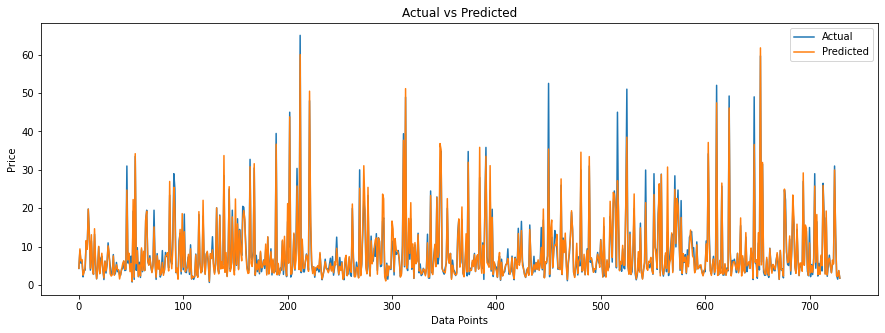

In [295]:
plt.figure(figsize=(15,5))
plt.plot(Y_test.values, label="Actual")
plt.plot(Y_predict, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Data Points")
plt.ylabel("Price")

plt.show()


In [296]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
pickle

<module 'pickle' from 'C:\\python310\\lib\\pickle.py'>